# Dependence Modeling with Copulas

In previous methods where we estimated VaR and ES by treating portfolio returns as a single series, we assume that the dependence structure between assets in the portfolio is fixed over time. We see that all models we tried so far all failed at some point, even for our best model (Filtered Historical Simulation). In this notebook, we examine the dependence structure between component assets over time and see if the added specification of dependence improves the estimation of VaR/ES.

In [1]:
import numpy as np
import pandas as pd
import pickle
import scipy.stats as stats
import openturns as ot
from itertools import combinations
from matplotlib import pyplot as plt

import sys
sys.path.append("../src")
from risklib.plot_utils import shade_regimes

In [2]:
# Load standardized residuals (filtered by GARCH)
roll_garch_vol = pd.read_csv("../outputs/roll_garch_vol.csv", parse_dates=[0], index_col=0)
roll_garch_mean = pd.read_csv("../outputs/roll_garch_mean.csv", parse_dates=[0], index_col=0)
with open("../outputs/roll_garch_res.pkl", 'rb') as f:
    roll_garch_res = pickle.load(f)

T = len(roll_garch_vol)
tickers = roll_garch_vol.columns[:-1]
weights = np.array([0.25, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10])

## Rolling Correlation 

In [3]:
window = 504
roll_resid_corr = {}
for t1,t2 in combinations(tickers,r=2):
    corr = np.full((T,), np.nan)
    for i in range(window, T):
        corr[i] = pd.concat([roll_garch_res[i][t1].std_resid, roll_garch_res[i][t2].std_resid], axis=1).corr().values[0,1]
    roll_resid_corr[f"{t1}-{t2}"] = corr
    
roll_resid_corr = pd.DataFrame(roll_resid_corr, index=roll_garch_vol.index)

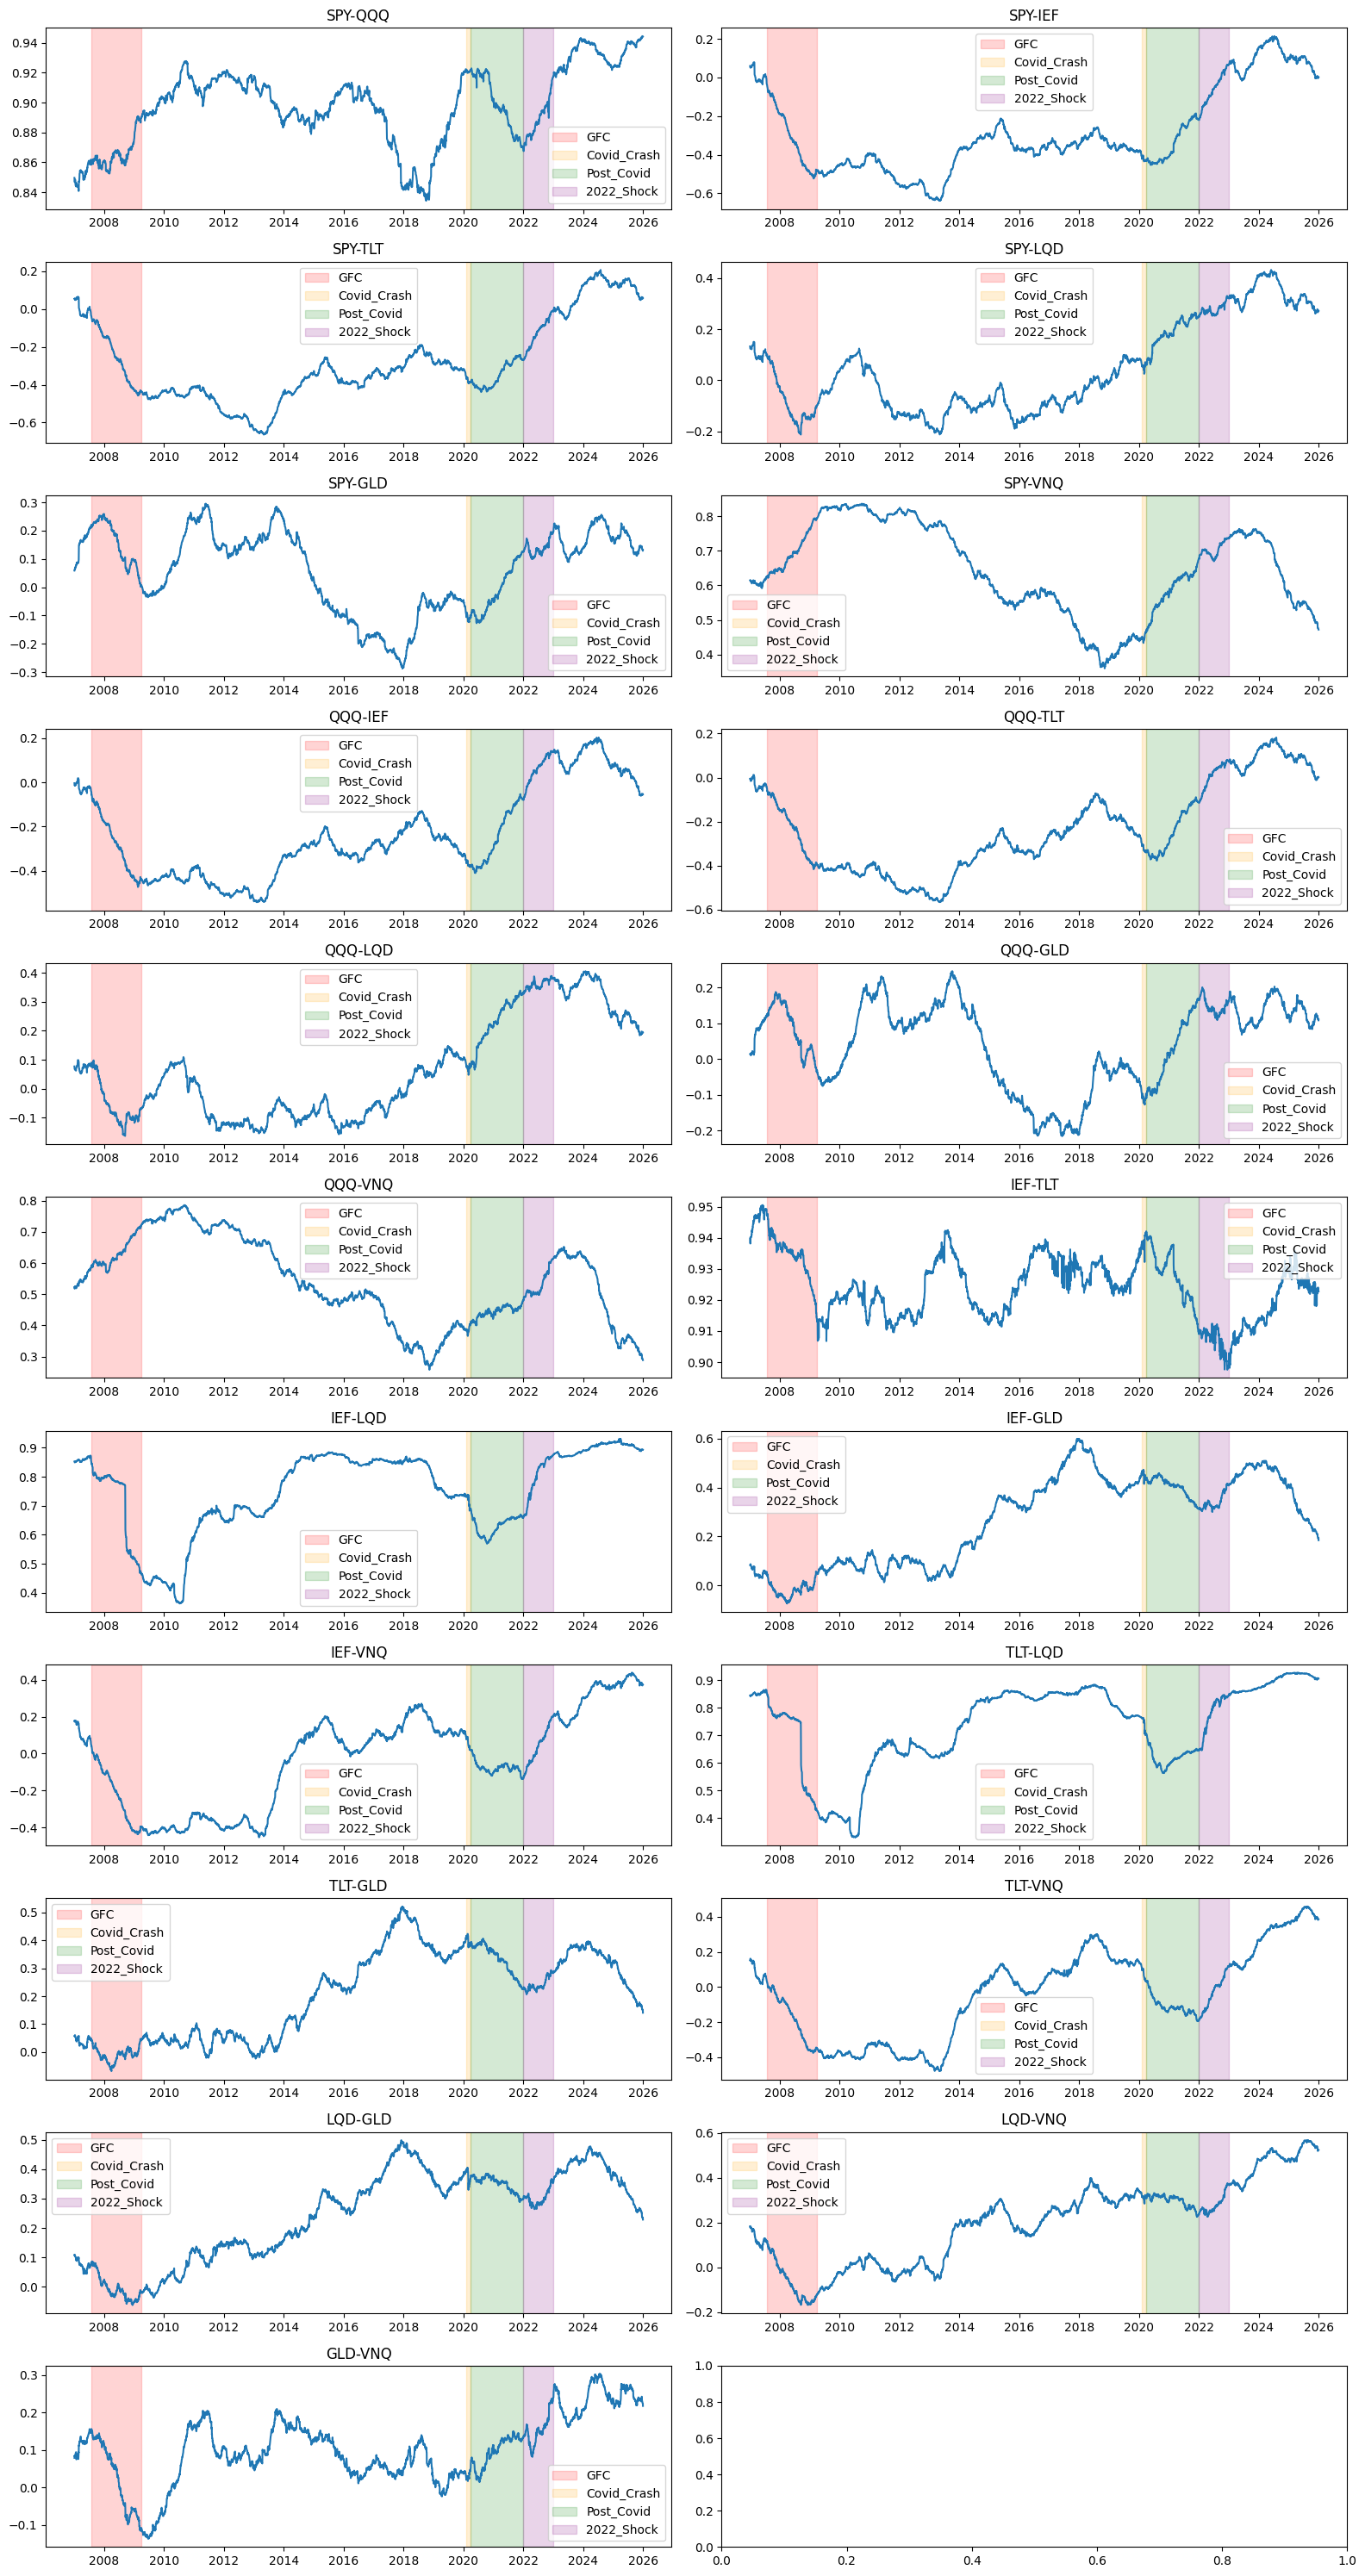

In [4]:
# Plot rolling correlation results
n_comb = len(list(combinations(tickers,r=2)))
fig, ax = plt.subplots(n_comb//2+1, 2, figsize=(16,30))
for comb,a in zip(roll_resid_corr.columns, ax.flat):
    a.plot(roll_resid_corr[comb])
    shade_regimes(a)
    a.legend()
    a.set_title(f"{comb}")
plt.tight_layout()

## Copulas

To fit standardize residuals to a copula, we need to 
1. Estimate distribution of each asset standardized residuals (we use empirical cdf here)
2. Transform the domain to [0,1] by applying an **CDF transform**
3. Fit transformed residuals to a parametric copula (Gaussian, t, Clayton etc)

In [5]:
# Using Empirical CDF and inverse CDF to construct copulas
def emp_cdf(data, samples):
    ''' Transform given data with the empirical CDF estimated using these data
    '''
    res =  stats.ecdf(data).cdf
    return res.evaluate(samples)

def emp_inv_cdf(data, probs):
    ''' Transform given probabilities with empirical inverse CDF (quantile) estiamted using given data
    '''
    return np.quantile(data, probs, method='inverted_cdf')
    
def build_copula_sample(resid_cdf, copula, sample_size=10000):
    ''' Build copula with transformed residuals and sample from it '''
    # Build copula with transformed residuals
    if copula == 'studentT':
        cmodel = ot.StudentCopulaFactory().build(ot.Sample(resid_cdf.values))
    elif copula == 'gaussian':
        cmodel = ot.NormalCopulaFactory().build(ot.Sample(resid_cdf.values))
    
    # Get sample from copula
    samples = cmodel.getSample(sample_size).asDataFrame()
    return samples

## VaR/ES Monte Carlo Estimation

In [6]:
def get_var_es_copula(garch_res, tickers, vol, mean, copula, weights, q):
    ''' Estimate portfolio VaR/ES using Monte Carlo methods with samples drawn from fitted copula
    '''
    # CDF transform
    resid_cdf = {}
    for ticker in tickers:
        data = garch_res[ticker].std_resid
        resid_cdf[ticker] = emp_cdf(data, data)
    resid_cdf = pd.DataFrame(resid_cdf, index=garch_res['SPY'].std_resid.index)
    
    # Build copula with transformed residuals and sample from it
    samples = build_copula_sample(resid_cdf, copula=copula, sample_size=10000)
    samples.columns = tickers
    
    # Inverse CDF transform samples
    resid_samples = {}
    for ticker in tickers:
        data = garch_res[ticker].std_resid
        probs = samples[ticker]
        resid_samples[ticker] = emp_inv_cdf(data, probs)
    resid_samples = pd.DataFrame(resid_samples)

    port_var, port_es = [], []
    for i in range(len(vol)):
        # Transform std residual samples back to returns
        return_samples = resid_samples * vol.iloc[i] + mean.iloc[i]
        # Calculate simulated portfolio returns
        port_return_samples = return_samples @ weights
        # Estimated VaR
        var = np.quantile(-port_return_samples, q)
        es = -port_return_samples[-port_return_samples > var].mean()
        port_var.append(var)
        port_es.append(es)
    return port_var, port_es


def roll_var_es_copula(roll_garch_res, tickers, roll_garch_vol, roll_garch_mean, copula, weights, window=504, step=21, q=0.99):
    T = len(roll_garch_vol)
    roll_var, roll_es = np.full((T,), np.nan), np.full((T,), np.nan)
    for i in range(window, T, step):
        n = min(step,T-i)
        var, es = get_var_es_copula(
            roll_garch_res[i],
            tickers,
            roll_garch_vol.iloc[i:i+n],
            roll_garch_mean.iloc[i:i+n],
            copula=copula,
            weights=weights,
            q=q,
        )
        for j in range(n):
            roll_var[i+j], roll_es[i+j] = var[j], es[j]
        if (i-window) % (10*step) == 0:
            print(f'window {i-window} portfolio VaR/ES estimation complete')
    roll_var = pd.DataFrame(roll_var, index=roll_garch_mean.index, columns=[f'port_var{int(100*q)}'])
    roll_es = pd.DataFrame(roll_es, index=roll_garch_mean.index, columns=[f'port_es{int(100*q)}'])
    return roll_var, roll_es

port_var99_Copula, port_es99_Copula = roll_var_es_copula(
    roll_garch_res, tickers, roll_garch_vol[tickers], roll_garch_mean[tickers], copula='studentT', weights=weights, window=504, step=21, q=0.99
)
port_var95_Copula, port_es95_Copula = roll_var_es_copula(
    roll_garch_res, tickers, roll_garch_vol[tickers], roll_garch_mean[tickers], copula='studentT', weights=weights, window=504, step=21, q=0.95
)

window 0 portfolio VaR/ES estimation complete
window 210 portfolio VaR/ES estimation complete
window 420 portfolio VaR/ES estimation complete
window 630 portfolio VaR/ES estimation complete
window 840 portfolio VaR/ES estimation complete
window 1050 portfolio VaR/ES estimation complete
window 1260 portfolio VaR/ES estimation complete
window 1470 portfolio VaR/ES estimation complete
window 1680 portfolio VaR/ES estimation complete
window 1890 portfolio VaR/ES estimation complete
window 2100 portfolio VaR/ES estimation complete
window 2310 portfolio VaR/ES estimation complete
window 2520 portfolio VaR/ES estimation complete
window 2730 portfolio VaR/ES estimation complete
window 2940 portfolio VaR/ES estimation complete
window 3150 portfolio VaR/ES estimation complete
window 3360 portfolio VaR/ES estimation complete
window 3570 portfolio VaR/ES estimation complete
window 3780 portfolio VaR/ES estimation complete
window 3990 portfolio VaR/ES estimation complete
window 4200 portfolio VaR/E

In [88]:
port_var99_Copula

,port_var99
Date,
2005-01-04,NaN
2005-01-05,NaN
2005-01-06,NaN
2005-01-07,NaN
2005-01-10,NaN
...,...
2025-12-23,0.014122
2025-12-24,0.013533
2025-12-26,0.013135


## Save output

In [7]:
port_var99_Copula.to_csv('../outputs/port_var99_Copula.csv', index=True)
port_es99_Copula.to_csv('../outputs/port_es99_Copula.csv', index=True)
port_var95_Copula.to_csv('../outputs/port_var95_Copula.csv', index=True)
port_es95_Copula.to_csv('../outputs/port_es95_Copula.csv', index=True)